In [1]:
pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils import data
import matplotlib.pyplot as plt
from collections import defaultdict

from tqdm import tqdm

In [3]:
df = torch.load(r'/kaggle/input/different-embedding/heterodata_object12.pt', weights_only=False,map_location=torch.device('cpu'))

In [4]:
df

HeteroData(
  item={
    x=[12101, 100],
    text=[12101],
    is_train=[12101],
  },
  (user, rated, item)={
    history={
      train={
        item_ID=[22363],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      valid={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
      test={
        item_ID=[22363, 15],
        item_ID_next=[22363],
        user_ID=[22363],
      },
    },
  }
)

In [5]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.output_dim = output_dim
        self.encoder = nn.Sequential()
        self.dims = [input_dim] + hidden_dims + [output_dim]
        for ind, inp_dim in enumerate(self.dims[:-1]):
            out_dim = self.dims[ind+1]
            cur_enc = nn.Linear(inp_dim, out_dim, bias = False)
            self.encoder.append(cur_enc)
            if ind != len(self.dims) - 2:
                self.encoder.append(nn.ReLU())
        
    def forward(self, x):
        return self.encoder(x)

In [6]:
class Codebook(nn.Module):
    def __init__(self, codebook_size, emb_dim, beta):
        super().__init__()
        self.beta = beta
        self.emb = nn.Embedding(codebook_size, emb_dim)
        nn.init.uniform_(self.emb.weight, -1.0, 1.0)

    def forward(self, x):
        code = self.emb.weight  
        dist = (
            (x ** 2).sum(dim=1, keepdim=True)
            + (code ** 2).sum(dim=1)
            - 2 * x @ code.T
        )
        ids = dist.argmin(dim=1)
        emb = self.emb(ids)
        loss = (
            F.mse_loss(emb, x.detach()) +
            self.beta * F.mse_loss(x, emb.detach())
        )
        emb_st = x + (emb - x).detach()
        return loss, emb_st, ids


In [7]:
class RQVAE(nn.Module):
    def __init__(self, inp_size, hidden_sizes, embed_dim,n_codebooks, n_layers, beta):
        super().__init__()
        self.inp_size = inp_size
        self.hidden_sizes = hidden_sizes
        self.emb_dim = embed_dim
        self.enc = Encoder(inp_size, hidden_sizes, embed_dim)
        self.dec = Encoder(embed_dim, hidden_sizes[-1::-1], inp_size)
        self.layers = nn.ModuleList(modules=[Codebook(n_codebooks, embed_dim, beta) for _ in range(n_layers)])
    
    def forward(self,x):
        encoded = self.enc(x)
        r = encoded
        q_losses = 0
        sids = []
        e_sum = torch.zeros(size=(x.shape[0], self.emb_dim), device = 'cuda' if torch.cuda.is_available() else 'cpu')
        for layer in self.layers:
            q_loss, emb, ids = layer(r)
            r = r-emb.detach()
            q_losses+= q_loss
            e_sum += emb
            sids.append(ids)
        dec = self.dec(e_sum)
        rec_loss = F.mse_loss(x, dec) 
        loss = q_losses + rec_loss
        return q_losses, rec_loss, loss, sids
            
            

In [8]:
class Data_Embeddings(Dataset):
    def __init__(self, data, related):
        super().__init__()
        self.data = data
        self.related = related
        
    def __getitem__(self, index):
        return index, self.data[index]
        
    def __len__(self):
        return self.data.shape[0]

In [9]:
def unique_per_level(SIDs):
    uns = []
    for sid in SIDs:
        uns.append(sid.unique().numel())
    return torch.tensor(uns, device = device)

In [10]:
embeds = df['item'].x
related = list(range(len(embeds)))
ds = Data_Embeddings(embeds,related)

In [11]:
train_rq, val_rq = data.random_split(ds, [0.9, 0.1])
print(len(val_rq))

1210


In [12]:
dl_train_rq = DataLoader(train_rq, batch_size = 1024, shuffle = True)
dl_val_rq = DataLoader(val_rq, batch_size = len(val_rq), shuffle= False)

In [13]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [14]:
lr = 0.4
n_layers = 3
beta = 0.25
hidden_sizes = [512, 256, 128]
embed_dim = 32
codebook_num = 2048
n_ep = 3000

In [32]:
rq_vae = RQVAE(embeds.shape[1], hidden_sizes, embed_dim, codebook_num, n_layers, beta).to(device)
optimizer = optim.Adagrad(rq_vae.parameters(), lr=lr)
history = {
    'train_total_loss':[],
    'train_recon_loss':[],
    'train_rq_loss':[],
    'train_sids_num':[],
    'val_total_loss':[],
    'val_recon_loss':[],
    'val_rq_loss':[],
    'val_sids_num':[]}

In [ ]:
for e in range(n_ep): 
    rq_vae.train() 
    loss_total_avg = 0 
    loss_recon_avg = 0 
    loss_rq_avg = 0 
    sids_number_avg = torch.zeros(size=(n_layers,), device = device) 
    train_tqdm = tqdm(dl_train_rq, leave = False, desc=f'train {e+1}/{n_ep}') 
    for ind, emb in train_tqdm: 
        emb = emb.to(device)
        pred = rq_vae(emb) 
        q_loss, r_loss, loss,  sids = pred
        loss_recon = r_loss
        un_sids = unique_per_level(sids)
        total_loss = loss
        train_tqdm.set_postfix( total=f"{total_loss.item():.4f}", quant=f"{q_loss.item():.4f}", recon=f"{loss_recon.item():.4f}", uniq = f"{un_sids.tolist()}") 
        optimizer.zero_grad() 
        total_loss.backward() 
        optimizer.step() 
        loss_total_avg += total_loss 
        loss_recon_avg += loss_recon 
        loss_rq_avg += q_loss 
        sids_number_avg += un_sids
    loss_total_avg = loss_total_avg/ len(dl_train_rq) 
    loss_recon_avg = loss_recon_avg/ len(dl_train_rq) 
    loss_rq_avg = loss_rq_avg/ len(dl_train_rq) 
    sids_number_avg = sids_number_avg/len(dl_train_rq) 
    history['train_total_loss'].append(loss_total_avg.item()) 
    history['train_recon_loss'].append(loss_recon_avg.item())
    history['train_rq_loss'].append(loss_rq_avg.item()) 
    history['train_sids_num'].append(sids_number_avg) 
    rq_vae.eval() 
    val_tqdm = tqdm(dl_val_rq, leave=False, desc = f'val {e+1}/{n_ep}') 
    loss_total_avg = 0 
    loss_recon_avg = 0 
    loss_rq_avg = 0 
    sids_number_avg = torch.zeros(size=(n_layers,), device = device) 
    with torch.no_grad(): 
        for ind, emb in val_tqdm: 
            emb = emb.to(device) 
            pred = rq_vae(emb) 
            q_loss, r_loss, loss,  sids = pred
            loss_recon = r_loss
            un_sids = unique_per_level(sids)
            total_loss = loss
            val_tqdm.set_postfix( total=f"{total_loss.item():.4f}", quant=f"{q_loss:.4f}", recon=f"{loss_recon.item():.4f}",uniq = f"{un_sids.tolist()}") 
            loss_total_avg += total_loss 
            loss_recon_avg += loss_recon
            loss_rq_avg += q_loss
            sids_number_avg += un_sids
        loss_total_avg = loss_total_avg/ len(dl_val_rq) 
        loss_recon_avg = loss_recon_avg/ len(dl_val_rq)
        loss_rq_avg = loss_rq_avg/ len(dl_val_rq)
        sids_number_avg = sids_number_avg/len(dl_val_rq) 
        history['val_total_loss'].append(loss_total_avg.item()) 
        history['val_recon_loss'].append(loss_recon_avg.item()) 
        history['val_rq_loss'].append(loss_rq_avg.item()) 
        history['val_sids_num'].append(sids_number_avg) 

train 1709/3000:  91%|█████████ | 10/11 [00:00<00:00, 94.67it/s, quant=44.5477, recon=0.1006, total=44.6483, uniq=[1, 132, 171]]               IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
ServerApp.rate_limit_window=1.0 (secs)

train 2902/3000:   0%|          | 0/11 [00:00<?, ?it/s, quant=38.6714, recon=0.1011, total=38.7725, uniq=[1, 187, 194]]          

In [34]:
sid_to_id = defaultdict(list)
id_to_sid = {}
rq_vae.eval()
with torch.no_grad():
    for ind, id_text  in enumerate(df['item'].text):
        text = id_text
        emb = df['item'].x[ind].to(device)
        emb = emb.view((1,-1))
        pred = rq_vae(emb)
        sids = pred[-1]
        sid = tuple(lvl.item() for lvl in sids)
        sid_to_id[sid].append(id)
        id_to_sid[id] = sid
        
        

In [35]:
id_to_fullsid = {}
num_colls = 0
for sid, ids in sid_to_id.items():
    if len(ids) == 1:
        id_to_fullsid[ids[0]] = sid
    else:
        num_colls+=len(ids)-1
        for cnt, id in enumerate(ids):
            id_to_fullsid[id] = (*sid, cnt)

In [36]:
n_unique_sid = len(sid_to_id)
n_collisions = sum(len(v) - 1 for v in sid_to_id.values())
max_cluster = max(len(v) for v in sid_to_id.values())
cfr = (len(ds) - n_collisions) / len(ds)
stats = pd.DataFrame({
    'unique_base_codes': [len(sid_to_id)],
    'collision_free_ratio': [cfr],
    'max_cluster_size': [max_cluster],
}, index=['RQ_VAE', ])
stats

,unique_base_codes,collision_free_ratio,max_cluster_size
RQ_VAE,7960,0.657797,13


In [37]:
def plot_losses(history):
    epochs = range(1, len(history["train_total_loss"]) + 1)
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, history["train_total_loss"], label="train total")
    plt.plot(epochs, history["val_total_loss"], label="val total")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Total loss")
    plt.yscale("log")
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(epochs, history["train_recon_loss"], label="train recon")
    plt.plot(epochs, history["train_rq_loss"], label="train quant")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train losses")
    plt.yscale("log")
    plt.legend()

    plt.subplot(1, 3, 3)
    plt.plot(epochs, history["val_recon_loss"], label="val recon")
    plt.plot(epochs, history["val_rq_loss"], label="val quant")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Val losses")
    plt.yscale("log")
    plt.legend()
    plt.savefig(fname = 'res_2.png')
    plt.show()


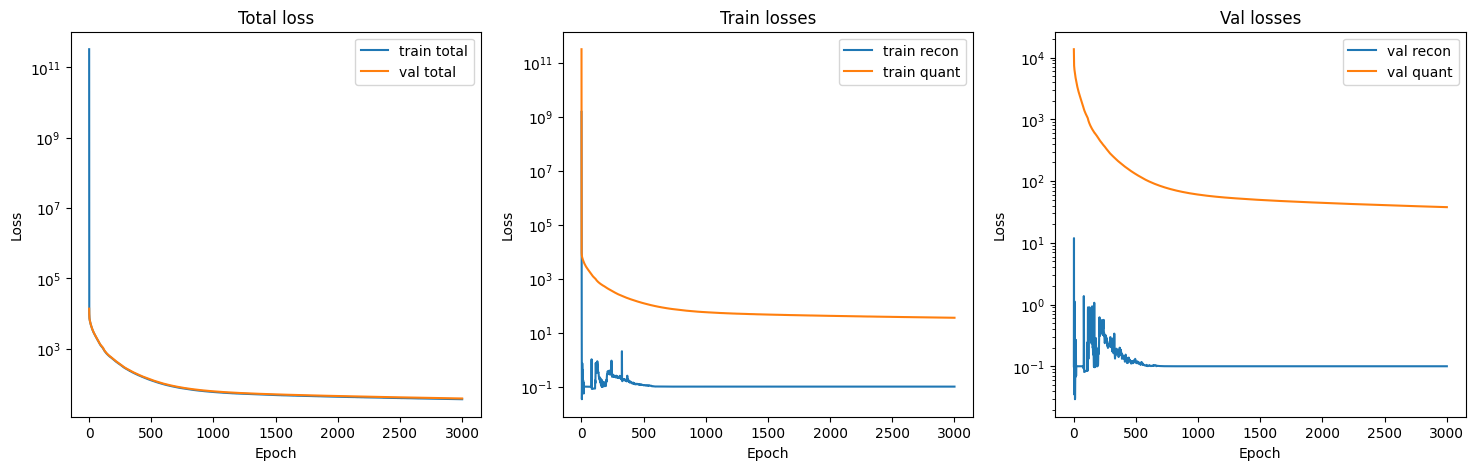

In [38]:
plot_losses(history)

In [39]:
def plot_SIDS(history):
    epochs = range(1, len(history["val_sids_num"]) + 1)
    sids_val, sids_train = np.asarray(torch.stack(history["val_sids_num"]).cpu()), np.asarray(torch.stack(history["train_sids_num"]).cpu())
    
    plt.figure(figsize= (18, 12))
    for i in range(sids_val.shape[1]):
        plt.subplot(3, 1, i+1)
        
        plt.plot(epochs, sids_train[:, i], label=f"train sids level {i}")
        plt.plot(epochs, sids_val[:, i], label=f"val sids number {i}")
        plt.xlabel("Epoch")
        plt.ylabel("SID number")
        plt.legend()
    plt.savefig(fname = 'res_1.png')
    plt.show()

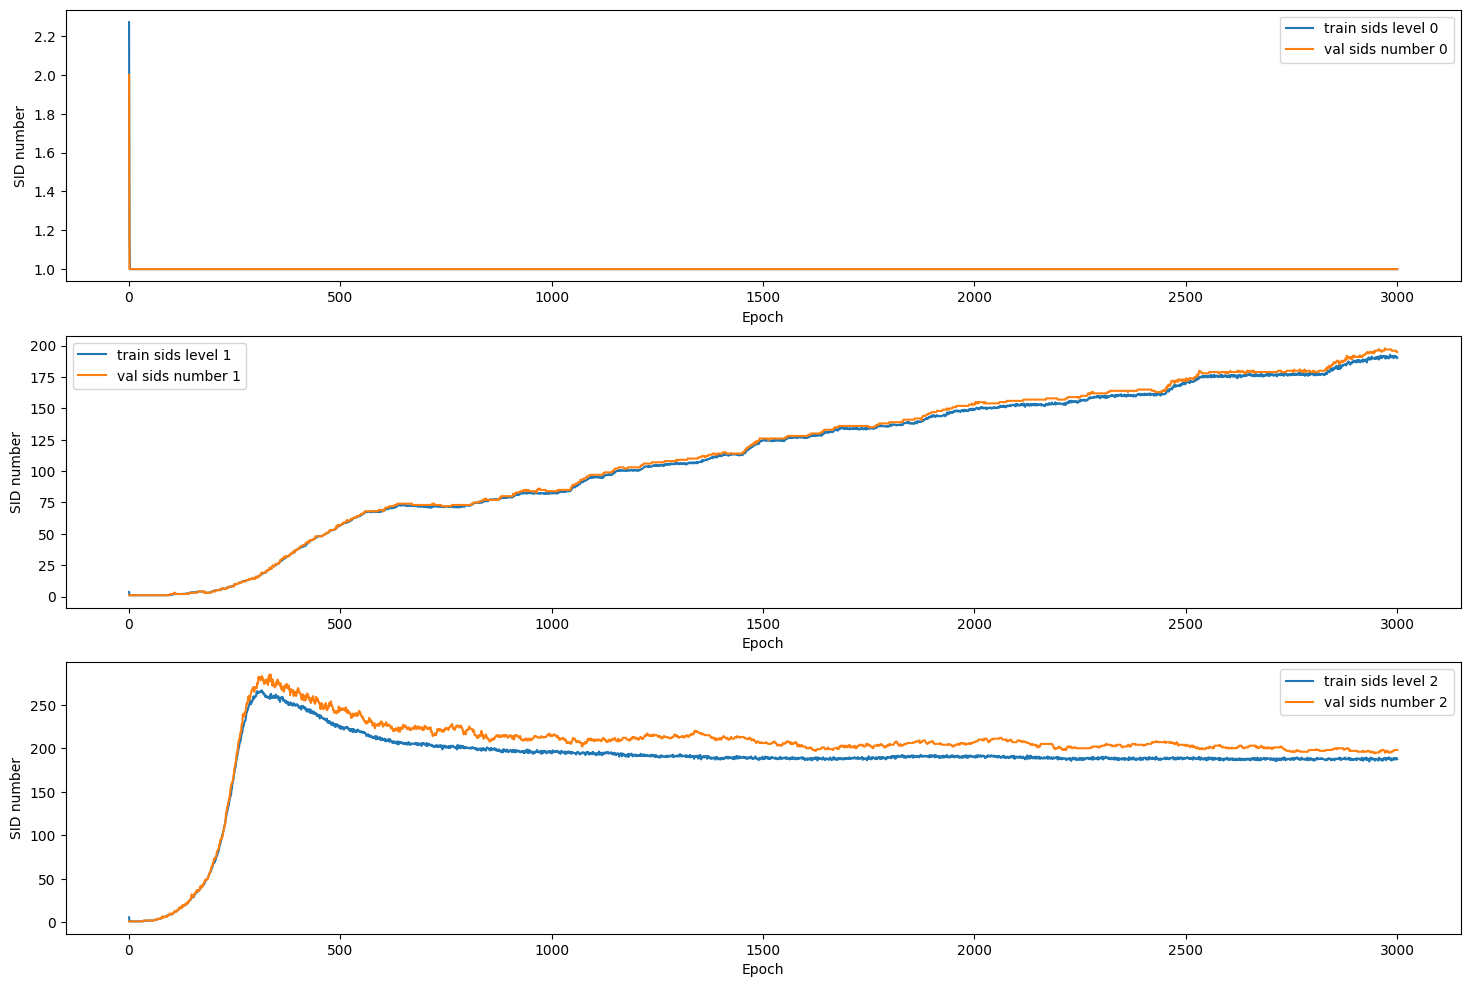

In [40]:
plot_SIDS(history)